# Datathon — EDA (Exploratory Data Analysis)

Bu notebook, `career_success_score` tahmin yarışmasının keşifsel veri analiz aşamasıdır.  
**Dosyalar:** `train.csv`, `test_x.csv` bu notebook ile **aynı klasörde** olmalı.

## 1. Kütüphaneleri yükle

- `pandas` → veriyi tablo (DataFrame) olarak okur, işler
- `numpy` → sayısal hesaplamalar (ortalama, log, vb.)
- `matplotlib` / `seaborn` → grafik çizimi
- `warnings` → gereksiz uyarıları susturur

! - `pip install pandas numpy matplotlib seaborn`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Grafik stili — temiz, sade görünüm
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams['figure.dpi'] = 110

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## 2. Veriyi oku

`pd.read_csv()` → CSV dosyasını bir DataFrame'e yükler.  
DataFrame'i Excel tablosu gibi düşün: satırlar = öğrenciler, sütunlar = özellikler.

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test_x.csv')

print(f'Train: {train.shape[0]} satır, {train.shape[1]} sütun')
print(f'Test : {test.shape[0]} satır, {test.shape[1]} sütun')

# İlk 3 satıra bak
train.head(3)

Train: 10000 satır, 47 sütun
Test : 10000 satır, 46 sütun


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,...,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,...,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,...,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,...,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...


## 3. Hedef değişkeni incele: `career_success_score`

Yarışmada tahmin edeceğimiz sütun bu.  
- Min / max → tahmin aralığı
- Ortalama vs medyan → dağılım simetrisi
- `%95 = 100` → tavan etkisi: çok sayıda öğrenci tam 100 almış

In [3]:
y = train['career_success_score']

print('=== Temel istatistikler ===')
print(y.describe().round(2))
print(f'\nYüzdelikler:')
for q in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]:
    print(f'  %{int(q*100):>3}: {y.quantile(q):.2f}')

=== Temel istatistikler ===
count    10000.00
mean        76.94
std         15.19
min          0.00
25%         66.94
50%         77.81
75%         88.47
max        100.00
Name: career_success_score, dtype: float64

Yüzdelikler:
  %  1: 38.33
  %  5: 50.09
  % 25: 66.94
  % 50: 77.81
  % 75: 88.47
  % 95: 100.00
  % 99: 100.00


### 3.1 Histogram — dağılımı görsel olarak incele

- Soldaki çubuklar düşük başarılı öğrenciler (az kişi)
- Sağdaki yığılma: tavan etkisi — MSE için önemli
- Kırmızı kesik çizgi: ortalama

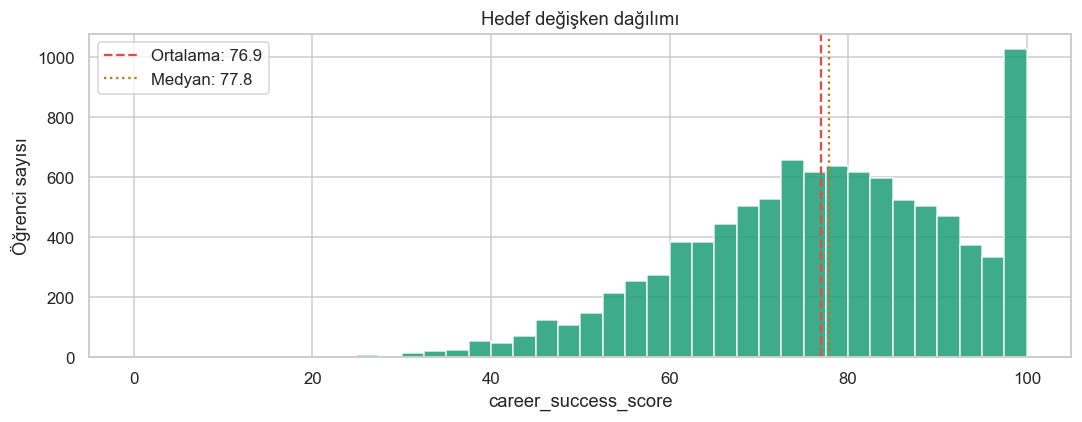

Grafik kaydedildi: plot_hedef_dagilim.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y, bins=40, color='#1D9E75', edgecolor='white', alpha=0.85)
ax.axvline(y.mean(), color='#E24B4A', ls='--', lw=1.5, label=f'Ortalama: {y.mean():.1f}')
ax.axvline(y.median(), color='#BA7517', ls=':', lw=1.5, label=f'Medyan: {y.median():.1f}')
ax.set_xlabel('career_success_score')
ax.set_ylabel('Öğrenci sayısı')
ax.set_title('Hedef değişken dağılımı')
ax.legend()
plt.tight_layout()
plt.savefig('plot_hedef_dagilim.png', bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: plot_hedef_dagilim.png')

## 4. Eksik veri analizi

`isna().sum()` → her sütundaki boş değer sayısı.  
Eksik veri **neden eksik** sorusunu sormak, sadece "nasıl doldurayım" sorusundan önemlidir.

In [5]:
miss = train.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(train) * 100).round(1)

miss_df = pd.DataFrame({'eksik_sayı': miss, 'eksik_%': miss_pct})
print(miss_df.to_string())

                                eksik_sayı  eksik_%
internship_duration_months            1657     16.6
english_exam_score                     953      9.5
github_avg_stars                       910      9.1
open_source_contribution_count         910      9.1
hr_interview_score                     780      7.8
linkedin_profile_score                 668      6.7
portfolio_score                        364      3.6


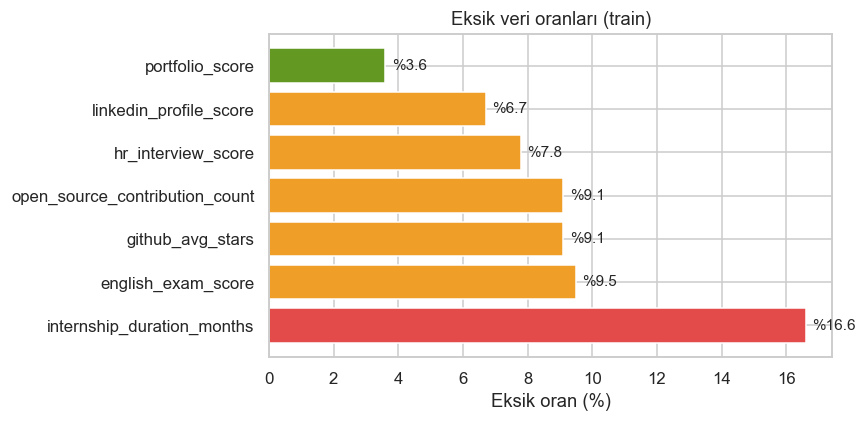

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E24B4A' if p > 10 else '#EF9F27' if p > 5 else '#639922'
          for p in miss_pct.values]
bars = ax.barh(miss_pct.index, miss_pct.values, color=colors, edgecolor='white')
ax.set_xlabel('Eksik oran (%)')
ax.set_title('Eksik veri oranları (train)')
for bar, val in zip(bars, miss_pct.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'%{val}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_eksik_veri.png', bbox_inches='tight')
plt.show()

### 4.1 Mantıksal eksiklik testi: staj süresi

Hipotez: `internship_duration_months` boşsa, `internship_count` sıfır mıdır?  
Eğer öyleyse, bu sütunu "0 staj = 0 süre" mantığıyla doldurabiliriz.

In [7]:
mask_bos = train['internship_duration_months'].isna()

print('=== Staj süresi EKSİK olanların staj sayısı ===')
print(train.loc[mask_bos, 'internship_count'].value_counts().sort_index())
print()
# Sonuç: Büyük çoğunluğu 0, ama hepsi değil.
# → Staj sayısı 0 olanlara 0, diğerlerine medyan atayacağız (Gün 1'de)

=== Staj süresi EKSİK olanların staj sayısı ===
internship_count
0    1361
1     165
2      87
3      31
4      10
5       3
Name: count, dtype: int64



## 5. Sayısal sütunların hedefle korelasyonu

**Pearson korelasyonu** → iki sayısal değişken arasındaki *doğrusal* ilişkinin gücü.  
- +1: mükemmel pozitif ilişki (biri artınca diğeri artar)
- 0: ilişki yok
- -1: mükemmel negatif ilişki

Dikkat: düşük korelasyon ≠ önemsiz sütun. Ağaç modelleri doğrusal olmayan ilişkileri de yakalar.

In [8]:
drop_cols = ['student_id', 'mentor_feedback_text', 'career_success_score']
num_cols  = [c for c in train.select_dtypes(include=[np.number]).columns
             if c not in drop_cols]

corrs = train[num_cols].corrwith(y).sort_values(ascending=False)
print(corrs.round(3).to_string())

project_quality_score             0.541
technical_interview_score         0.340
problem_solving_score             0.290
cloud_score                       0.277
coding_score                      0.274
devops_score                      0.272
portfolio_score                   0.271
backend_score                     0.267
real_client_project_count         0.259
data_structures_score             0.252
sql_score                         0.251
machine_learning_score            0.243
communication_score               0.237
frontend_score                    0.232
github_repo_count                 0.227
open_source_contribution_count    0.198
github_avg_stars                  0.153
freelance_project_count           0.109
hr_interview_score                0.107
presentation_score                0.098
teamwork_score                    0.071
cv_quality_score                  0.070
internship_duration_months        0.054
hackathon_awards                  0.049
interviews_attended               0.039


### 5.1 Korelasyon çubuk grafiği

Yeşil → güçlü (≥0.25), turuncu → orta (0.10–0.25), gri → zayıf, kırmızı → negatif

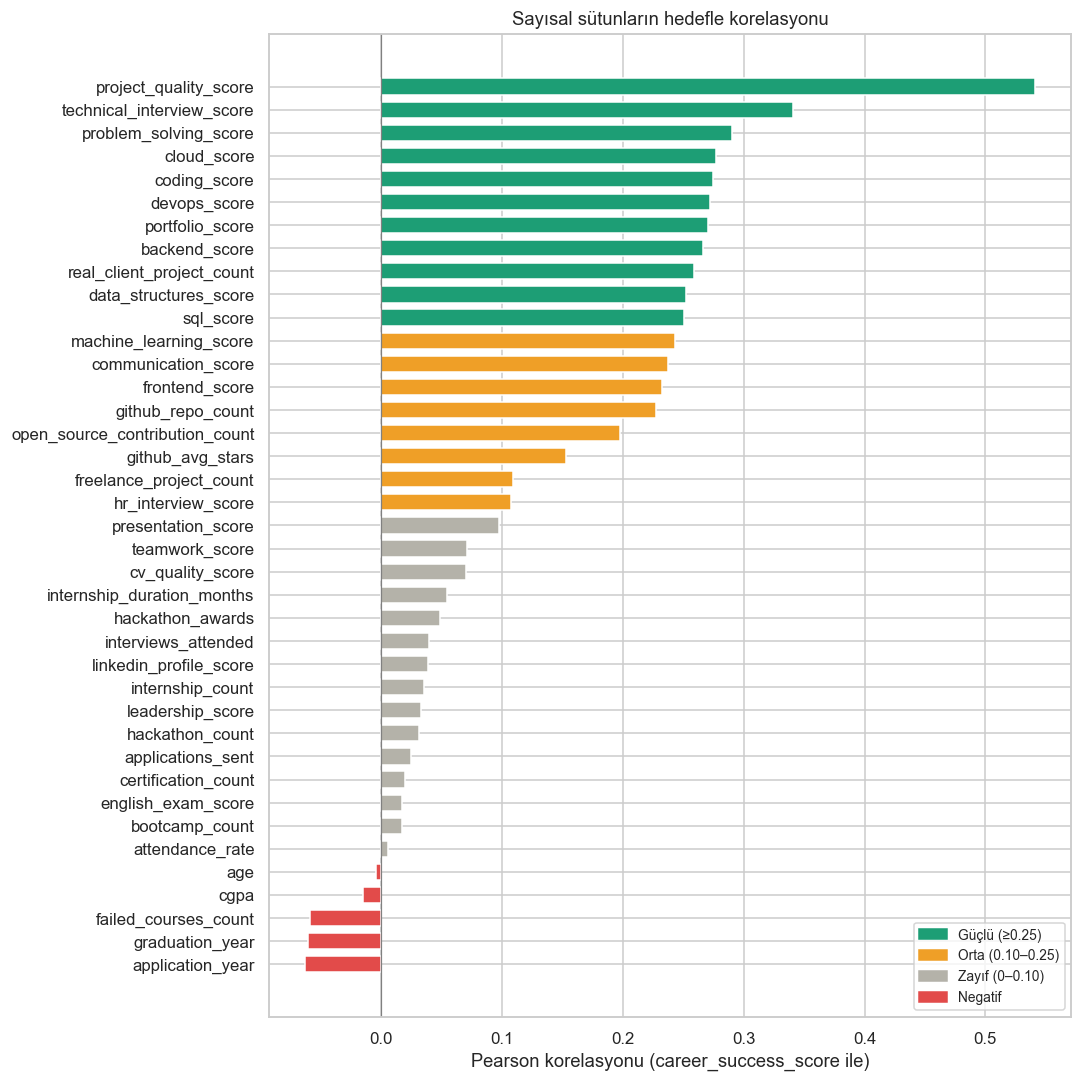

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
bar_colors = ['#1D9E75' if v >= 0.25 else
              '#EF9F27' if v >= 0.10 else
              '#B4B2A9' if v >= 0 else '#E24B4A'
              for v in corrs.values]
ax.barh(corrs.index[::-1], corrs.values[::-1], color=bar_colors[::-1],
        edgecolor='white', height=0.7)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Pearson korelasyonu (career_success_score ile)')
ax.set_title('Sayısal sütunların hedefle korelasyonu')

# Renk açıklaması
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#1D9E75', label='Güçlü (≥0.25)'),
    Patch(color='#EF9F27', label='Orta (0.10–0.25)'),
    Patch(color='#B4B2A9', label='Zayıf (0–0.10)'),
    Patch(color='#E24B4A', label='Negatif'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('plot_korelasyon.png', bbox_inches='tight')
plt.show()

## 6. Korelasyon ısı haritası (heatmap)

Önemli sayısal sütunların **birbirleriyle** korelasyonu.  
- Yüksek korelasyonlu iki sütun birlikte modele girerse, birbirini tekrar eder (multicollinearity).
- Bunu görmek feature seçimi için yararlı.

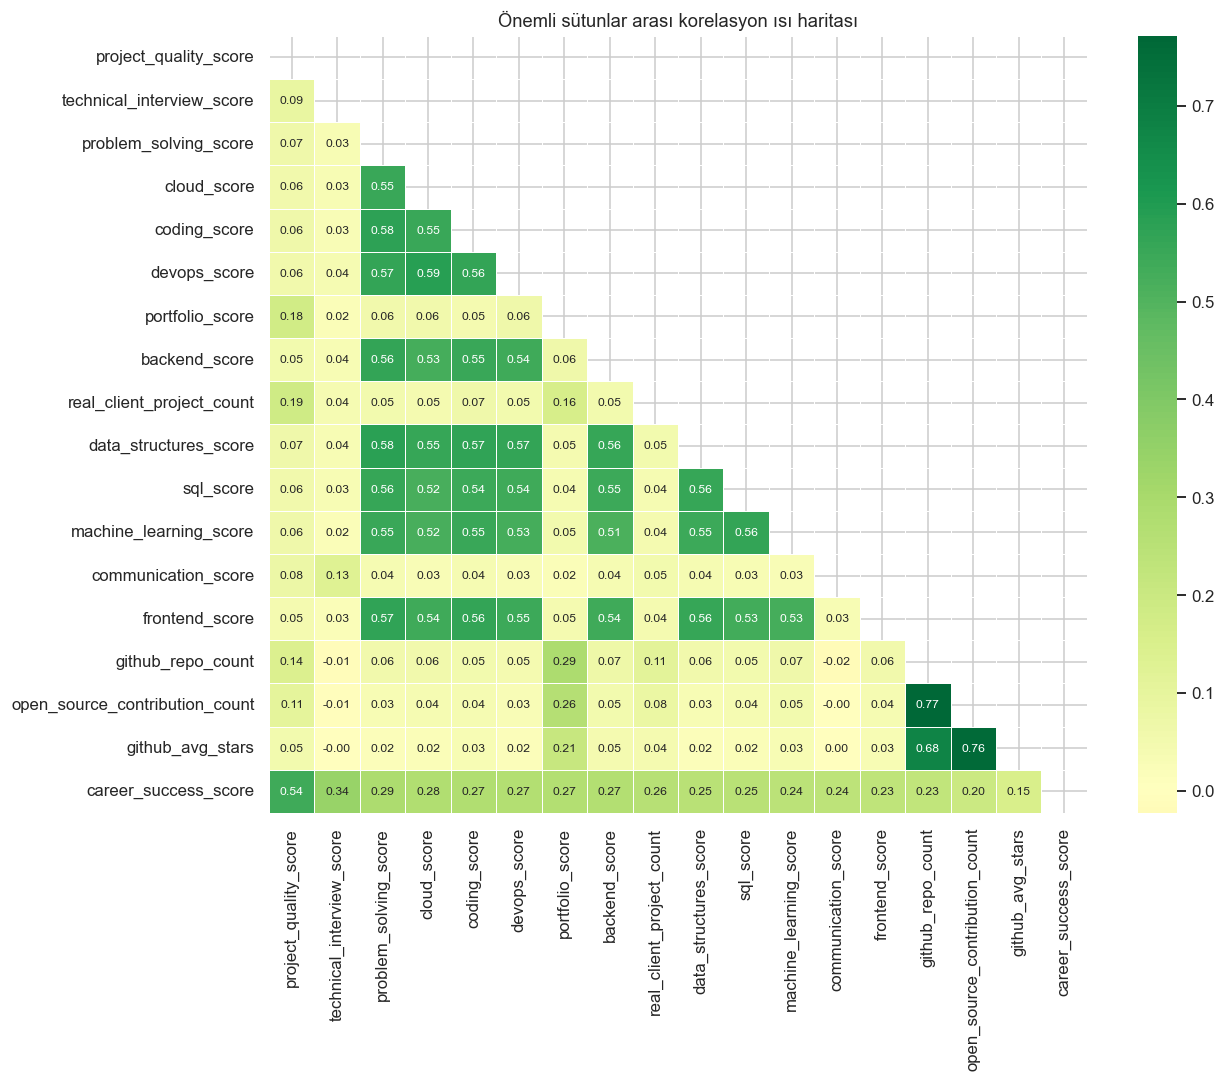

Grafik kaydedildi: plot_heatmap.png


In [10]:
# Korelasyonu 0.15'in üzerinde olan sütunları seçelim (görsel okunabilirlik için)
important_cols = corrs[corrs.abs() >= 0.15].index.tolist() + ['career_success_score']
corr_matrix = train[important_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # üst üçgeni gizle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Önemli sütunlar arası korelasyon ısı haritası')
plt.tight_layout()
plt.savefig('plot_heatmap.png', bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: plot_heatmap.png')

## 7. Çarpık dağılımlı sütunlar

**Çarpıklık (skewness):** Dağılım simetrik değilse, birkaç çok yüksek değer ortalamayı çekiyor demektir.  
MSE büyük hataları ağır cezalandırır → uç değerler modeli yanıltır.  
`log(x + 1)` dönüşümü bu uç değerleri "yumuşatır".  
+1 ekliyoruz çünkü `log(0)` tanımsız — sıfır değerleri olan satırlar varsa hata verirdi.

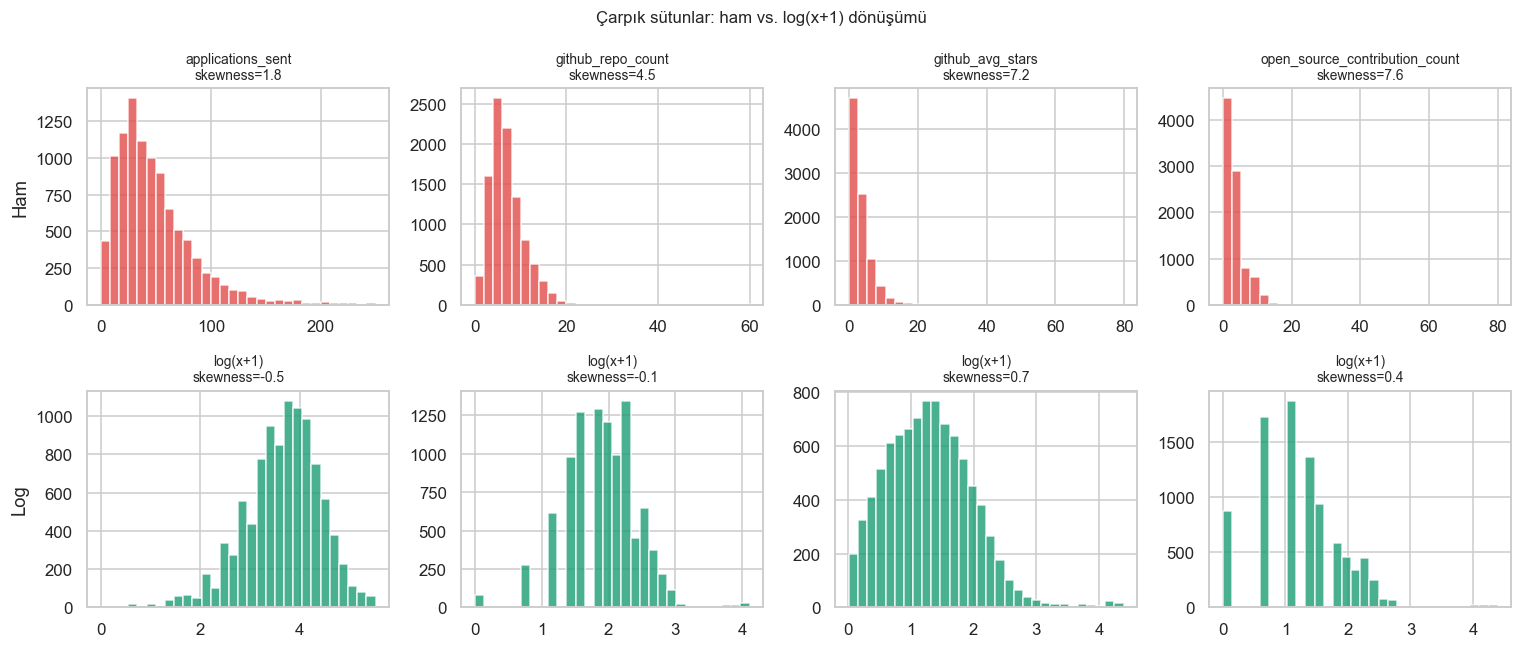

In [11]:
skewed_cols = ['applications_sent', 'github_repo_count',
               'github_avg_stars', 'open_source_contribution_count']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i, col in enumerate(skewed_cols):
    data = train[col].dropna()
    # Ham dağılım
    axes[0, i].hist(data, bins=30, color='#E24B4A', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\nskewness={data.skew():.1f}', fontsize=9)
    axes[0, i].set_ylabel('Ham' if i == 0 else '')
    # Log dönüşümü
    log_data = np.log1p(data)  # log1p = log(x+1)
    axes[1, i].hist(log_data, bins=30, color='#1D9E75', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'log(x+1)\nskewness={log_data.skew():.1f}', fontsize=9)
    axes[1, i].set_ylabel('Log' if i == 0 else '')

fig.suptitle('Çarpık sütunlar: ham vs. log(x+1) dönüşümü', fontsize=11)
plt.tight_layout()
plt.savefig('plot_carpiklik.png', bbox_inches='tight')
plt.show()

## 8. Kategorik sütunlar — grup ortalamaları

Her kategorinin ortalama `career_success_score`'u.  
Gruplar arası fark büyükse → sütun ayrıştırıcı, modele katkısı yüksek.  
Fark küçükse → olası çeldirici (red herring).

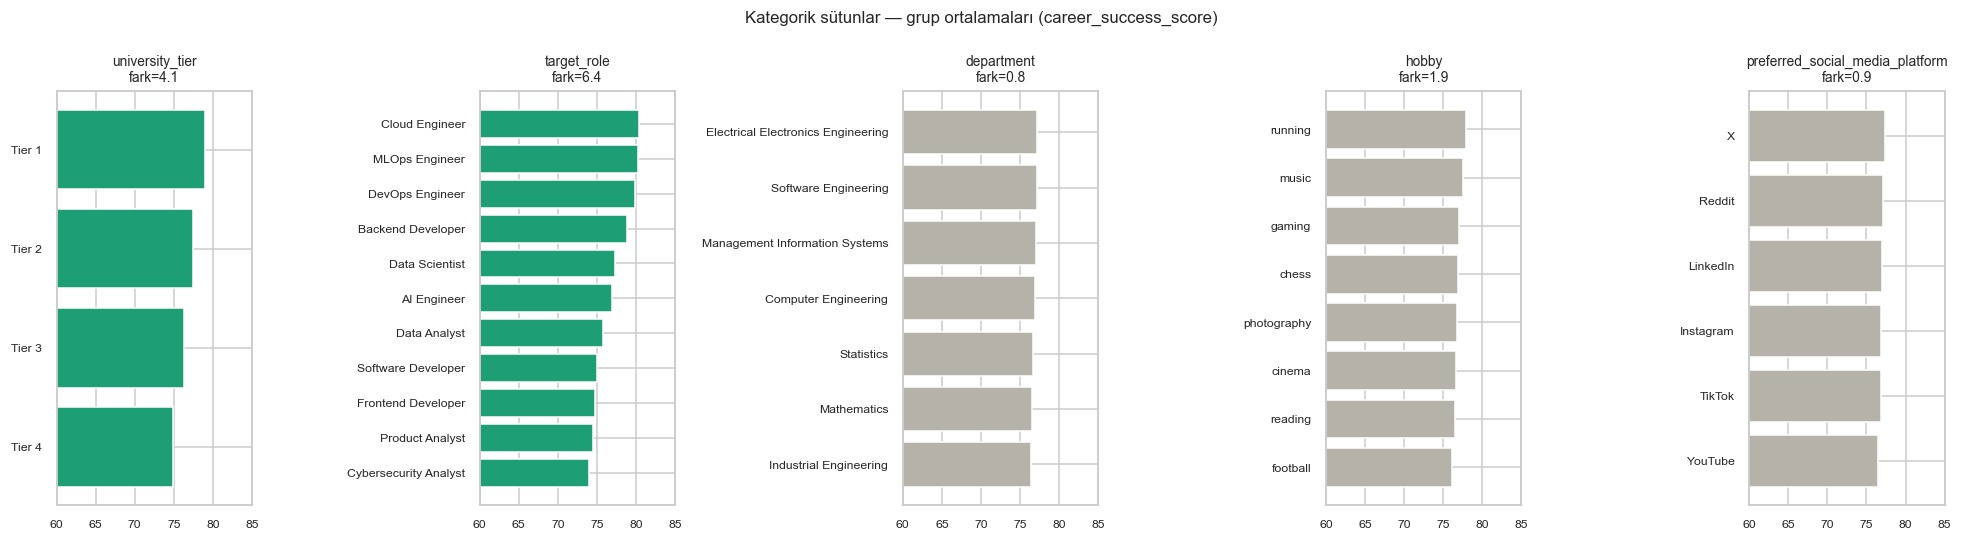

In [12]:
cat_cols = ['university_tier', 'target_role', 'department',
            'hobby', 'preferred_social_media_platform']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))

for ax, col in zip(axes, cat_cols):
    group_means = (train.groupby(col)['career_success_score']
                   .mean()
                   .sort_values(ascending=True))
    spread = group_means.max() - group_means.min()
    color = '#1D9E75' if spread >= 4 else '#EF9F27' if spread >= 2 else '#B4B2A9'
    ax.barh(group_means.index, group_means.values,
            color=color, edgecolor='white')
    ax.set_title(f'{col}\nfark={spread:.1f}', fontsize=9)
    ax.set_xlim(60, 85)
    ax.tick_params(labelsize=8)

fig.suptitle('Kategorik sütunlar — grup ortalamaları (career_success_score)', fontsize=11)
plt.tight_layout()
plt.savefig('plot_kategorik.png', bbox_inches='tight')
plt.show()

## 9. En güçlü sütun — scatter plot

`project_quality_score` korelasyonu 0.54 ile açık ara en yüksek.  
Scatter plot → iki sayısal değişken arasındaki ilişkiyi nokta bulutu olarak gösterir.

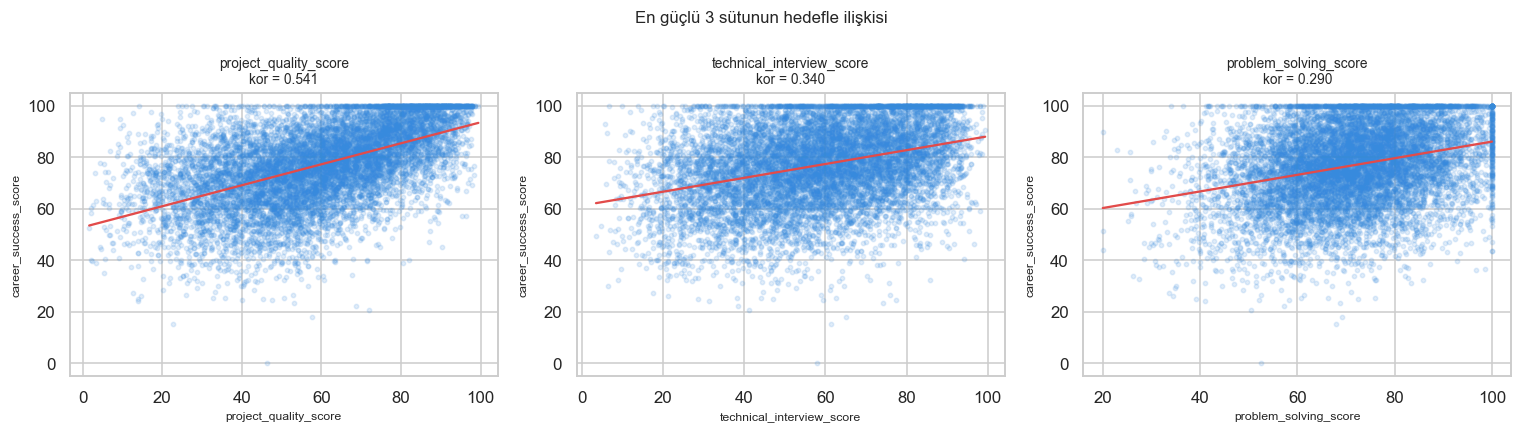

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

top3 = ['project_quality_score', 'technical_interview_score', 'problem_solving_score']
for ax, col in zip(axes, top3):
    ax.scatter(train[col], y, alpha=0.15, s=8, color='#378ADD')
    # Trend çizgisi
    m, b = np.polyfit(train[col].dropna(),
                      y[train[col].notna()], 1)
    xs = np.linspace(train[col].min(), train[col].max(), 100)
    ax.plot(xs, m*xs+b, color='#E24B4A', lw=1.5)
    corr_val = train[col].corr(y)
    ax.set_title(f'{col}\nkor = {corr_val:.3f}', fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('career_success_score', fontsize=8)

plt.suptitle('En güçlü 3 sütunun hedefle ilişkisi', fontsize=11)
plt.tight_layout()
plt.savefig('plot_scatter.png', bbox_inches='tight')
plt.show()

## 10. Mentor metin analizi — ön bakış

`mentor_feedback_text` yarışmanın NLP ayrışma noktası.  
Bugün sadece **karakter sayısı ile hedef arasındaki ilişkiye** bakıyoruz.  
Gerçek NLP (TF-IDF, duygu analizi, BERTurk) → Gün 3.

In [14]:
train['metin_uzunluk'] = train['mentor_feedback_text'].fillna('').str.split().str.len()

print(f"Metin uzunluğu — min: {train['metin_uzunluk'].min()}, "
      f"max: {train['metin_uzunluk'].max()}, "
      f"ortalama: {train['metin_uzunluk'].mean():.0f} kelime")

# Pozitif/negatif kelime basit sayımı
pozitif_kelimeler = ['güçlü', 'dikkat çek', 'etkileyici', 'başarılı', 'mükemmel',
                     'potansiyel', 'yüksek', 'iyi', 'parlak', 'öne çıkar']
negatif_kelimeler = ['geliştirmesi', 'yetersiz', 'düşük', 'çalışması gerekiyor',
                     'eksik', 'ihtiyaç', 'zorlan']

text = train['mentor_feedback_text'].fillna('').str.lower()
train['poz_count'] = sum(text.str.count(k) for k in pozitif_kelimeler)
train['neg_count'] = sum(text.str.count(k) for k in negatif_kelimeler)
train['duygu_fark'] = train['poz_count'] - train['neg_count']

print(f"\nDuygu farkı (poz-neg) — hedefle korelasyon: {train['duygu_fark'].corr(y):.3f}")
print("→ Bu ham sözlük yöntemiyle bile anlamlı bir korelasyon görülüyor.")
print("  Gün 3'te bunu TF-IDF ve BERTurk ile çok daha iyi yapacağız.")

Metin uzunluğu — min: 17, max: 59, ortalama: 33 kelime

Duygu farkı (poz-neg) — hedefle korelasyon: 0.325
→ Bu ham sözlük yöntemiyle bile anlamlı bir korelasyon görülüyor.
  Gün 3'te bunu TF-IDF ve BERTurk ile çok daha iyi yapacağız.


## 11. EDA özet — ne öğrendik?

| Bulgu | Anlamı | Aksiyon |
|-------|--------|---------|
| `project_quality_score` kor=0.54 | Tek başına en güçlü feature | Modelin bel kemiği |
| 9 teknik skor tutarlı 0.23–0.29 | Birlikte güçlü | Ortalama/max/std türet (Gün 2) |
| `mentor_feedback_text` ham duygu kor>0 | NLP ile çok daha güçlü olacak | Gün 3 |
| %95 dilim = 100 (tavan etkisi) | Tahminleri clip(0,100) | Zaten baseline'da uygulandı |
| `hobby`, `social_media` grup farkı <2 | Olası çeldirici | Çıkarma deneyi (Gün 2) |
| `internship_duration` %16.6 eksik | Mantıksal eksiklik | Staj=0 → süre=0 (Gün 1) |
| `github_avg_stars` skewness=7.2 | Uç değerler MSE'yi patlatır | log(x+1) dönüşümü (Gün 2) |

**Baseline CV MSE:** 85.1 → bu sayıyı yenmek için çalışıyoruz. 🎯